In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
import mdata_utils 
import TCR_embedings
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [18]:
df = pd.read_csv(r".\raw features\tcr_emb_all.csv")

In [19]:
sig_LF_index = [10,20,22,36,38,39,41]

In [49]:
df['subtype']

0             CD8_Tem
1       CD8_Trm_exh_L
2             CD8_Tem
3             CD8_Tem
4             CD8_Tem
            ...      
6747    CD8_Trm_exh_L
6748    CD8_Trm_exh_H
6749    CD8_Trm_exh_L
6750          CD8_Tem
6751          CD8_Tem
Name: subtype, Length: 6752, dtype: object

In [60]:
subtype = ["CD8_Trm_exh_L", "CD8_Trm_exh_H", "CD8_Trm_exh_M"]
# "CD8_Teff", "CD8_Tem", 
# clone_status = ["Tumor_single"]


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, spearmanr

# r_s, p_s = spearmanr(mana, col)
# r_p, p_p = spearmanr(mana, col)

mask = df['subtype'].isin(subtype) 
# & df['clone_status'].isin(clone_status)
df_sub = df[mask].copy().reset_index(drop=True)

# df_sub = df

feature_cols = df.columns[5:]
X = df_sub[feature_cols].values
y = df_sub['MANAscore'].values

print(f"Subset: {len(df_sub)} cells  |  Features: {len(feature_cols)}")
print(f"MANAscore range: [{y.min():.4f}, {y.max():.4f}]  mean={y.mean():.4f}")

Subset: 3298 cells  |  Features: 242
MANAscore range: [0.0535, 0.9612]  mean=0.4724


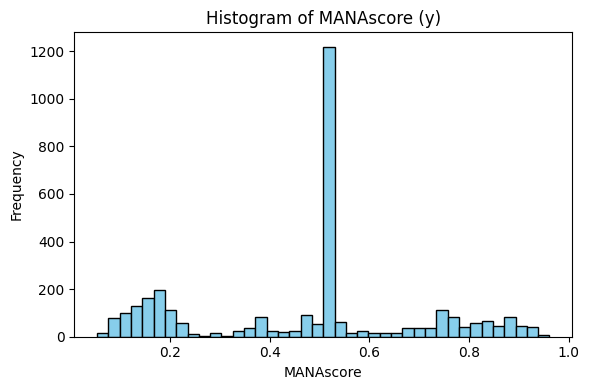

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y, bins=40, color='skyblue', edgecolor='black')
plt.xlabel("MANAscore")
plt.ylabel("Frequency")
plt.title("Histogram of MANAscore (y)")
plt.tight_layout()
plt.show()

In [63]:
## Linear regression with ALL features (col 5+) ##
scaler_all = StandardScaler()
X_scaled = scaler_all.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# lr_all = LinearRegression()
from xgboost import XGBRegressor
lr_all = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    reg_alpha=5.0,        # higher L1 → more feature weights zeroed (was 2.0)
    reg_lambda=15.0,      # higher L2 → shrinks weights (was 10.0)
    gamma=1.0,            # min loss reduction to make a split — add this
)

lr_all.fit(X_train, y_train)
y_train_pred = lr_all.predict(X_train)

y_pred = lr_all.predict(X_test)

r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
mse = mean_squared_error(y_test, y_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
corr, pval = spearmanr(y_test, y_pred)
corr_train, pval_train = spearmanr(y_train, y_train_pred)

print("=" * 60)
print(f"XGBoost Regression — ALL features ({len(feature_cols)})")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Test R²: {r2:.4f}   MSE: {mse:.6f}   Pearson r: {corr:.4f} (p={pval:.4g})")
print(f"Train R²: {r2_train:.4f}   MSE: {mse_train:.6f}   Pearson r: {corr_train:.4f} (p={pval_train:.4g})")
print("=" * 60)

XGBoost Regression — ALL features (242)
Train: 2638  |  Test: 660
Test R²: 0.0611   MSE: 0.050738   Pearson r: 0.3187 (p=4.804e-17)
Train R²: 0.0686   MSE: 0.048969   Pearson r: 0.3542 (p=7.815e-79)


In [64]:
import os

slide_dir = r".\TCR_MANA_all_0.1_0.4_out"

slide_features = []
for idx in sig_LF_index:
    fpath = os.path.join(slide_dir, f"feature_list_Z{idx}.txt")
    fl = pd.read_csv(fpath, sep="\t")
    names = fl['names'].dropna().tolist()
    names = [n for n in names if n != "NA"]
    slide_features.extend(names)
    print(f"Z{idx}: {len(names)} features")

slide_features = sorted(set(slide_features))
valid_slide = [f for f in slide_features if f in feature_cols]
missing = [f for f in slide_features if f not in feature_cols]

print(f"\nTotal unique SLIDE features: {len(slide_features)}")
print(f"Matched in df: {len(valid_slide)}")
if missing:
    print(f"Missing from df: {missing}")

Z10: 15 features
Z20: 18 features
Z22: 17 features
Z36: 19 features
Z38: 18 features
Z39: 19 features
Z41: 20 features

Total unique SLIDE features: 46
Matched in df: 45
Missing from df: ['clone_id_size']


In [ ]:
## Linear regression with SLIDE-selected features ##
X_slide = df_sub[valid_slide].values

scaler_slide = StandardScaler()
X_slide_scaled = scaler_slide.fit_transform(X_slide)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_slide_scaled, y, test_size=0.2, random_state=42
)

# lr_slide = LinearRegression()
lr_slide = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    reg_alpha=5.0,        # higher L1 → more feature weights zeroed (was 2.0)
    reg_lambda=15.0,      # higher L2 → shrinks weights (was 10.0)
    gamma=1.0,            # min loss reduction to make a split — add this    
)

lr_slide.fit(X_tr_s, y_tr_s)
y_pred_s = lr_slide.predict(X_te_s)
r2_s = r2_score(y_te_s, y_pred_s)
mse_s = mean_squared_error(y_te_s, y_pred_s)
corr_s, pval_s = spearmanr(y_te_s, y_pred_s)

y_train_pred_s = lr_slide.predict(X_tr_s)

r2_s_train = r2_score(y_tr_s, y_train_pred_s)
mse_s_train = mean_squared_error(y_tr_s, y_train_pred_s)
corr_s_train, pval_s_train = spearmanr(y_tr_s, y_train_pred_s)

print("=" * 60)
print(f"XGBoost Regression — SLIDE features ({len(valid_slide)})")
print(f"Train: {len(X_tr_s)}  |  Test: {len(X_te_s)}")
print(f"Test R²: {r2_s:.4f}   MSE: {mse_s:.6f}   Pearson r: {corr_s:.4f} (p={pval_s:.4g})")
print(f"Train R²: {r2_s_train:.4f}   MSE: {mse_s_train:.6f}   Pearson r: {corr_s_train:.4f} (p={pval_s_train:.4g})")
print("=" * 60)

print(f"\n--- Comparison ---")
print(f"ALL features  ({len(feature_cols):>3d}):  R²={r2:.4f}  MSE={mse:.6f}  r={corr:.4f}")
print(f"SLIDE features ({len(valid_slide):>3d}):  R²={r2_s:.4f}  MSE={mse_s:.6f}  r={corr_s:.4f}")

XGBoost Regression — SLIDE features (45)
Train: 2638  |  Test: 660
Test R²: 0.0379   MSE: 0.051990   Pearson r: 0.2352 (p=9.486e-10)
Train R²: 0.0410   MSE: 0.050422   Pearson r: 0.2433 (p=7.313e-37)

--- Comparison ---
ALL features  (242):  R²=0.0611  MSE=0.050738  r=0.3187
SLIDE features ( 45):  R²=0.0379  MSE=0.051990  r=0.2352


## Classification (binarized MANAscore)

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler

threshold = np.median(y)
y_cls = (y >= threshold).astype(int)

print(f"MANAscore threshold (median): {threshold:.4f}")
print(f"Class distribution: 0(low)={np.sum(y_cls==0)}, 1(high)={np.sum(y_cls==1)}")

MANAscore threshold (median): 0.5122
Class distribution: 0(low)=1249, 1(high)=2049


In [67]:
## Logistic regression with ALL features (col 5+) ##
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    scaler_all.fit_transform(X), y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

ros_c = RandomOverSampler(random_state=42)
X_train_c_bal, y_train_c_bal = ros_c.fit_resample(X_train_c, y_train_c)

from xgboost import XGBClassifier
# --- XGBoost with 5-fold stratified CV ---
clf_all = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

# clf_all = LogisticRegression(max_iter=1000, random_state=42)

clf_all.fit(X_train_c_bal, y_train_c_bal)

y_pred_c = clf_all.predict(X_test_c)
y_prob_c = clf_all.predict_proba(X_test_c)[:, 1]

acc_c = accuracy_score(y_test_c, y_pred_c)
try:
    auc_c = roc_auc_score(y_test_c, y_prob_c)
except ValueError:
    auc_c = np.nan

print("=" * 60)
print(f"Logistic Regression — ALL features ({len(feature_cols)})")
print(f"Train(balanced): {len(X_train_c_bal)}  |  Test: {len(X_test_c)}")
print(f"Accuracy: {acc_c:.4f}   ROC AUC: {auc_c:.4f}")
print("=" * 60)
print(classification_report(y_test_c, y_pred_c,
                            target_names=["MANA_low", "MANA_high"],
                            zero_division=0))

Logistic Regression — ALL features (242)
Train(balanced): 3278  |  Test: 660
Accuracy: 0.6682   ROC AUC: 0.7196
              precision    recall  f1-score   support

    MANA_low       0.56      0.56      0.56       250
   MANA_high       0.73      0.73      0.73       410

    accuracy                           0.67       660
   macro avg       0.65      0.65      0.65       660
weighted avg       0.67      0.67      0.67       660



In [68]:
## Logistic regression with SLIDE-selected features ##
X_tr_sc, X_te_sc, y_tr_sc, y_te_sc = train_test_split(
    scaler_slide.fit_transform(df_sub[valid_slide].values), y_cls,
    test_size=0.2, random_state=42, stratify=y_cls
)

ros_sc = RandomOverSampler(random_state=42)
X_tr_sc_bal, y_tr_sc_bal = ros_sc.fit_resample(X_tr_sc, y_tr_sc)

clf_slide = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

# clf_slide = LogisticRegression(max_iter=1000, random_state=42)
clf_slide.fit(X_tr_sc_bal, y_tr_sc_bal)

y_pred_sc = clf_slide.predict(X_te_sc)
y_prob_sc = clf_slide.predict_proba(X_te_sc)[:, 1]

acc_sc = accuracy_score(y_te_sc, y_pred_sc)
try:
    auc_sc = roc_auc_score(y_te_sc, y_prob_sc)
except ValueError:
    auc_sc = np.nan

print("=" * 60)
print(f"Logistic Regression — SLIDE features ({len(valid_slide)})")
print(f"Train(balanced): {len(X_tr_sc_bal)}  |  Test: {len(X_te_sc)}")
print(f"Accuracy: {acc_sc:.4f}   ROC AUC: {auc_sc:.4f}")
print("=" * 60)
print(classification_report(y_te_sc, y_pred_sc,
                            target_names=["MANA_low", "MANA_high"],
                            zero_division=0))

print(f"\n--- Classification Comparison ---")
print(f"ALL features  ({len(feature_cols):>3d}):  Acc={acc_c:.4f}  AUC={auc_c:.4f}")
print(f"SLIDE features ({len(valid_slide):>3d}):  Acc={acc_sc:.4f}  AUC={auc_sc:.4f}")

Logistic Regression — SLIDE features (45)
Train(balanced): 3278  |  Test: 660
Accuracy: 0.6576   ROC AUC: 0.7118
              precision    recall  f1-score   support

    MANA_low       0.55      0.55      0.55       250
   MANA_high       0.73      0.72      0.72       410

    accuracy                           0.66       660
   macro avg       0.64      0.64      0.64       660
weighted avg       0.66      0.66      0.66       660


--- Classification Comparison ---
ALL features  (242):  Acc=0.6682  AUC=0.7196
SLIDE features ( 45):  Acc=0.6576  AUC=0.7118
